# Assignment 2 – Zero-Shot Image Classification with Transformers

In this assignment, you will apply a pre-trained vision–language transformer (e.g. CLIP) to perform **zero-shot** classification on the Fashion-MNIST dataset—classifying each image without any task-specific training. You will build on the concepts from Assignment 1 by comparing this “off-the-shelf” approach to the CNN you previously trained.

You will:
1. **Load** the Fashion-MNIST images using PyTorch instead of Keras.
2. **Run a zero-shot baseline** with simple text prompts to set a performance reference.
3. **Engineer improved prompts** and measure the resulting accuracy gains.
4. **Visualise image embeddings** with UMAP to inspect class separability.
5. **Conduct one mini-experiment** of your choice.
6. **Summarise findings** and reflect on strengths and weaknesses of zero-shot transformers versus a trained CNN.

# 1. Loading the Fashion-MNIST Dataset

As in assignment 1, we'll load the Fashion-MNIST dataset, but this time using `torchvision.datasets` to ensure compatibility with the `transformers` library. We will also load our model and processor from the `transformers` library.

The transformers library allows us to use pre-trained models like CLIP, which can perform zero-shot classification by leveraging the text prompts we provide. There are two key objects we will use: the `CLIPModel` for the model itself and the `CLIPProcessor` for preparing our images and text prompts.

Since we are not actually training a model in this assignment, we will set the CLIP model to evaluation mode. If the model is designed to utilize features like dropout or batch normalization, setting it to evaluation mode ensures that these features behave correctly during inference (prediction). Setting the model to evaluaton mode also tells PyTorch that we don't have to compute gradients, which can save memory and speed up inference.

In order to speed up processing, we will also move the model to an "accelerator" if available. This is typically a GPU, but modern MacBooks also have an "Apple Silicon" accelerator that can be used for inference, called MPS (Metal Performance Shaders). If you are using a MacBook with Apple Silicon, you can use the MPS device for faster processing.

In [8]:
# Uncomment and run if required
!pip install transformers torchvision torch accelerate

In [11]:
pip uninstall -y torch torchvision transformers

Found existing installation: torch 2.8.0
Uninstalling torch-2.8.0:
  Successfully uninstalled torch-2.8.0
Found existing installation: torchvision 0.23.0
Uninstalling torchvision-0.23.0:
  Successfully uninstalled torchvision-0.23.0
Found existing installation: transformers 4.44.2
Uninstalling transformers-4.44.2:
  Successfully uninstalled transformers-4.44.2
Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install torch==2.4.1 torchvision transformers==4.44.2

  Using cached torchvision-0.23.0-cp39-cp39-macosx_11_0_arm64.whl.metadata (6.1 kB)
  Using cached transformers-4.44.2-py3-none-any.whl.metadata (43 kB)
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 MB 8.5 MB/s  0:00:07 eta 0:00:01
Using cached transformers-4.44.2-py3-none-any.whl (9.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 11.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [transformers] [transformers]
Note: you may need to restart the kernel to use updated packages.


In [1]:
from transformers import CLIPModel, CLIPProcessor
import torch

clip_model_name = "openai/clip-vit-base-patch32"
clip_model     = CLIPModel.from_pretrained(clip_model_name)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name, use_fast=False)

# Set model to evaluation mode, as we are not training it
clip_model.eval()

# Check for accelerators
device = "cpu" # Default to CPU
if torch.cuda.is_available():
    device = "cuda" # Use GPU if available
elif torch.backends.mps.is_available():
    device = "mps"

clip_model.to(device)

print(f"Using device: {device}")

/Users/adamhealey/miniforge3/envs/dsi_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/adamhealey/miniforge3/envs/dsi_env/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Using device: mps


Now we are ready to load the testing set from Fashion-MNIST. We will use the `torchvision.datasets.FashionMNIST` class to load the dataset. We do not need to apply any transformations to the images, as the `CLIPProcessor` ensures any input images are in the format that the model is trained on.

You should:

- [ ] Use the `torchvision.datasets.FashionMNIST` class to load the *test* split of the dataset. Documentation is available [here](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html).
- [ ] Create a PyTorch `DataLoader` to iterate over the dataset in batches. Use a batch size of 16 and set `shuffle=True` to randomise the order of the images. You will also need to supply the provided `collate_clip` function to the `DataLoader collate_fn` argument to ensure the images are processed correctly. Documentation for `DataLoader` is available [here](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

In [2]:
from torchvision import datasets
from torch.utils.data import DataLoader

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

def collate_clip(batch):
    imgs, labels = zip(*batch) # Unzip the batch into images and labels
    proc = clip_processor(images=list(imgs),
                        return_tensors="pt",
                        padding=True) # Process images with CLIPProcessor
    # Send pixel_values to GPU/CPU now; labels stay on CPU for metrics
    return proc["pixel_values"].to(device), torch.tensor(labels)

test_dataset = datasets.FashionMNIST(train= False,
                                     root="/Users/adamhealey/Desktop/UofT_DSI",
                                     download=True)
test_loader = torch.utils.data.DataLoader(test_dataset, 
                                          batch_size= 16, 
                                          shuffle=True,
                                          collate_fn=collate_clip)

If your code is correct, the following cell should show the first batch of images from the Fashion-MNIST dataset:

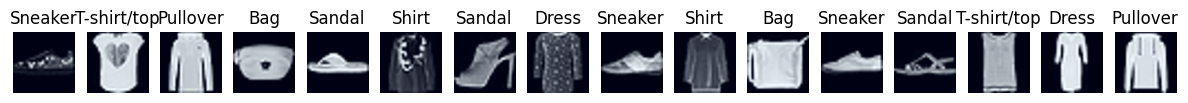

In [64]:
import matplotlib.pyplot as plt

# Display the first batch of images from `test_loader`

def show_batch(loader):
    images, labels = next(iter(loader))
    images = images.cpu()  # Move images to CPU for plotting
    # Renormalize to [0, 1] for visualization
    images = (images - images.min()) / (images.max() - images.min())
    _, axes = plt.subplots(1, len(images), figsize=(15, 5))
    for ax, img, label in zip(axes, images, labels):
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(CLASS_NAMES[label.item()])
        ax.axis('off')
    plt.show()

show_batch(test_loader)

We’re now ready to run our zero-shot classification baseline!

# Brief Introduction to Zero-Shot Classification

In Assignment 1, we followed the typical machine-learning pipeline: we trained a CNN on the Fashion-MNIST dataset, using labelled examples to update the model’s weights. While effective, that approach requires a curated, task-specific training set—a luxury you don’t always have in practice.

Zero-shot classification flips the script.  A large vision–language model (VLM) such as **CLIP** is first pre-trained on hundreds of millions of image–text pairs scraped from the web.  Because it learns *joint* visual–textual embeddings, the model can later solve new tasks simply by “measuring” how similar an image is to a **text prompt** that describes each candidate class—without seeing a single task-labelled example.

**How it works**  
1. Feed an image through CLIP’s vision encoder → **image feature**.  
2. Feed a textual prompt (e.g. “a photo of a sandal”) through CLIP’s text encoder → **text feature**.  
3. Compute cosine similarity between the image feature and every class’s text feature.  
4. Pick the class whose prompt is most similar.

For our first attempt, we’ll use the bare class names as prompts, e.g.:

- "T-shirt/top"
- "Trouser"

### You should:

- [ ] Build embeddings: use the `get_text_embeddings` helper function to create text embeddings for the class names.
- [ ] Run inference: use the `get_image_embeddings` helper function to create image embeddings.
- [ ] Compute cosine similarity: complete and use the `get_cosine_similarity` helper function to compute the cosine similarity between the image and text embeddings.
- [ ] Make predictions: use the `get_predictions` helper function to get the predicted class for each image in the batch.

Note that for normalized vectors like the ones we are using, cosine similarity is equivalent to the dot product. This means we can use the handy formula `cosine_similarity = vector_a @ vector_b.T` to compute the similarity between the image and text embeddings.

In [4]:
def get_text_embeddings(class_names: list[str]) -> torch.Tensor:
    """    Get text embeddings for the given class names using CLIP.
    Args:
        class_names (list[str]): List of class names to encode.
    Returns:
        torch.Tensor: Normalized text embeddings for the class names.
    """
    tokenized = clip_processor(text=class_names,
                               padding=True,
                               return_tensors="pt").to(device)
    
    with torch.no_grad():
        text_embeddings = clip_model.get_text_features(**tokenized)

    text_feats = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

    return text_feats

def get_image_embeddings(images: torch.Tensor) -> torch.Tensor:
    """    Get image embeddings for the given images using CLIP.
    Args:
        images (torch.Tensor): Batch of images to encode.
    Returns:
        torch.Tensor: Normalized image embeddings for the images.
    """
    with torch.no_grad():
        image_embeddings = clip_model.get_image_features(pixel_values=images)

    image_feats = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)

    return image_feats

In [ ]:
import numpy as np

def get_cosine_similarity(image_feats: torch.Tensor, text_feats: torch.Tensor) -> np.ndarray:
    """
    Compute cosine similarity between image features and text features.
    Args:
        image_feats (torch.Tensor): Image features of shape (N, D).
        text_feats (torch.Tensor): Text features of shape (M, D).
    Returns:
        numpy.ndarray: Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    """
    #Cosine similarity matrix is shape (N, M) so text_feats will need to be transposed
    image_feats = image_feats.cpu()  
    text_feats = text_feats.cpu()    

    image_feats = image_feats / image_feats.norm(dim=1, keepdim=True)
    text_feats = text_feats / text_feats.norm(dim=1, keepdim=True)
    #dot product of image and text features
    similarity = image_feats @ text_feats.T
    # Compute cosine similarity, which is the dot product of normalized vectors
    return similarity

def get_predictions(similarity: np.ndarray) -> np.ndarray:
    """
    Get predictions based on cosine similarity scores.
    Args:
        similarity (numpy.ndarray): Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    Returns:
        numpy.ndarray: Predicted class indices for each image, shape (N,).
    """
    # Get the index of the maximum similarity for each image
    best_index = np.argmax(similarity, axis=1)
    
    return best_index
    return # Complete

With these functions complete, you are ready to run the zero-shot classification baseline. Complete the code to follow these steps:

- [ ] Build text embeddings for the class names using the `get_text_embeddings` function (this only needs to be done once).
- [ ] For each batch of images:
    - [ ] Get image embeddings using the `get_image_embeddings` function.
    - [ ] Compute cosine similarity between the image and text embeddings using the `get_cosine_similarity` function.
    - [ ] Save the predictions so that we can build a confusion matrix later.
- [ ] Report the accuracy of the predictions and the confusion matrix using the `accuracy_score` and `confusion_matrix` functions from `sklearn.metrics`.

Test accuracy: 0.624


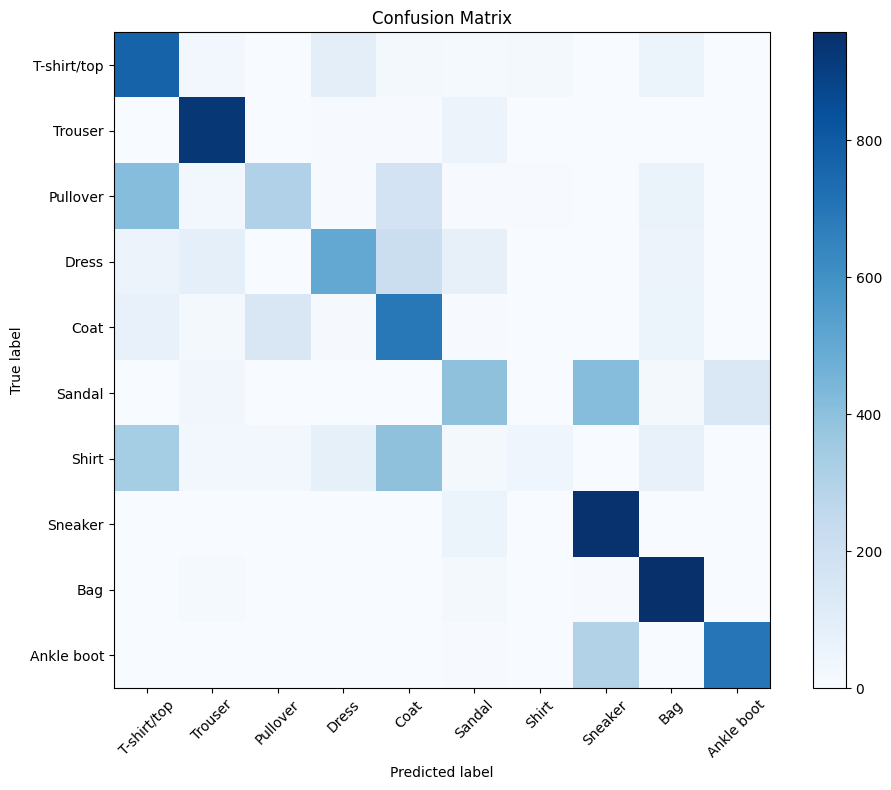

In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix

textEmbed = get_text_embeddings(CLASS_NAMES)
#print(textEmbed)
y_true, y_pred = [], []

for pixel_values, labels in test_loader:
    features = get_image_embeddings(pixel_values)
    batch_similarity = get_cosine_similarity(features, textEmbed)  # shape: (batch_size, num_classes)
    
    # Pick the class with highest similarity
    predicted_classes = torch.argmax(batch_similarity, dim=1)
    
    # Append to lists
    y_true.extend(labels.cpu().numpy())  # convert labels to numpy
    y_pred.extend(predicted_classes.cpu().numpy())  # convert predictions to numpy

# Report the accuracy
accuracy = accuracy_score(y_true, y_pred)
print("Test accuracy:", accuracy)
# # Report the confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()
plot_confusion_matrix(y_true, y_pred, CLASS_NAMES)

In [24]:
print(y_true)

[6, 4, 4, 5, 0, 3, 1, 8, 6, 3, 7, 8, 1, 6, 7, 6, 1, 7, 7, 4, 7, 5, 2, 1, 2, 3, 6, 5, 6, 5, 4, 0, 1, 7, 4, 4, 2, 5, 7, 7, 9, 3, 3, 9, 3, 8, 5, 2, 9, 7, 2, 3, 7, 0, 9, 8, 1, 8, 0, 2, 1, 7, 1, 9, 9, 6, 7, 1, 8, 9, 3, 8, 4, 1, 3, 6, 2, 6, 6, 3, 0, 8, 1, 9, 9, 7, 7, 4, 4, 8, 7, 0, 1, 9, 2, 3, 6, 7, 7, 4, 4, 7, 9, 7, 4, 4, 9, 8, 0, 6, 3, 3, 8, 1, 8, 8, 1, 2, 8, 2, 7, 8, 2, 6, 1, 3, 4, 0, 8, 8, 1, 2, 0, 8, 2, 2, 7, 0, 3, 7, 4, 3, 9, 0, 1, 8, 0, 4, 6, 2, 1, 8, 4, 1, 1, 9, 0, 7, 2, 3, 8, 1, 2, 3, 1, 0, 3, 0, 4, 3, 9, 7, 8, 9, 5, 8, 7, 1, 6, 2, 8, 1, 1, 1, 7, 4, 6, 1, 8, 9, 8, 5, 3, 9, 3, 2, 2, 2, 7, 2, 1, 6, 2, 3, 6, 9, 0, 7, 5, 2, 1, 8, 3, 6, 5, 6, 9, 7, 8, 5, 4, 2, 1, 5, 2, 7, 5, 1, 4, 3, 1, 9, 5, 6, 3, 9, 7, 3, 0, 7, 3, 6, 4, 6, 8, 2, 1, 5, 9, 9, 4, 4, 2, 9, 9, 1, 6, 0, 8, 4, 3, 7, 8, 2, 1, 5, 6, 8, 9, 9, 5, 2, 1, 2, 7, 1, 6, 2, 2, 7, 7, 8, 2, 9, 9, 0, 3, 7, 4, 1, 9, 3, 4, 6, 9, 1, 4, 6, 5, 0, 2, 2, 6, 2, 8, 6, 1, 4, 8, 1, 5, 0, 4, 0, 0, 6, 9, 7, 7, 3, 7, 3, 2, 5, 3, 3, 8, 8, 4, 1, 1, 9, 9, 

In [25]:
print(y_pred)

[4, 2, 4, 5, 0, 3, 1, 8, 4, 4, 7, 8, 1, 4, 7, 0, 1, 7, 7, 4, 5, 5, 2, 5, 0, 1, 0, 5, 4, 9, 4, 3, 1, 7, 0, 4, 4, 1, 7, 7, 9, 7, 3, 9, 0, 8, 7, 1, 9, 7, 2, 0, 7, 0, 9, 8, 5, 8, 8, 2, 1, 7, 1, 9, 9, 0, 7, 1, 8, 7, 1, 8, 4, 1, 3, 8, 2, 4, 4, 3, 0, 8, 1, 9, 9, 5, 7, 4, 4, 8, 7, 3, 1, 7, 0, 4, 3, 7, 7, 4, 4, 7, 9, 7, 4, 4, 9, 8, 0, 8, 3, 3, 5, 1, 8, 8, 1, 8, 8, 2, 7, 8, 1, 0, 8, 3, 4, 0, 8, 8, 1, 0, 0, 8, 0, 2, 7, 0, 3, 7, 4, 1, 9, 3, 1, 8, 0, 4, 5, 2, 1, 8, 1, 1, 1, 7, 3, 7, 0, 3, 8, 1, 2, 1, 1, 0, 0, 0, 2, 3, 9, 7, 8, 9, 5, 8, 7, 1, 3, 8, 8, 1, 1, 1, 7, 3, 0, 1, 8, 9, 8, 7, 3, 9, 3, 0, 2, 2, 7, 2, 1, 4, 0, 5, 8, 9, 0, 5, 9, 0, 5, 8, 4, 0, 7, 4, 9, 7, 8, 7, 8, 0, 1, 5, 2, 7, 9, 1, 2, 3, 1, 9, 9, 4, 3, 9, 7, 4, 0, 7, 3, 6, 2, 4, 8, 2, 1, 5, 7, 7, 4, 4, 0, 9, 7, 1, 2, 8, 8, 0, 3, 7, 8, 4, 1, 7, 4, 8, 9, 7, 5, 2, 1, 0, 7, 1, 0, 0, 2, 7, 7, 8, 0, 7, 9, 0, 1, 7, 2, 1, 9, 3, 4, 0, 9, 1, 4, 1, 7, 6, 2, 6, 3, 4, 8, 4, 1, 4, 8, 1, 9, 0, 8, 5, 3, 4, 7, 7, 7, 3, 7, 4, 1, 5, 3, 3, 8, 8, 4, 1, 1, 7, 9, 

In [7]:
cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)

Confusion matrix:
 [[769  25   2  95  18  14  19   0  58   0]
 [  0 931   0   5   5  56   0   0   3   0]
 [415  25 306   6 174   7   4   0  63   0]
 [ 56  87   2 504 216  77   2   1  53   2]
 [ 74  19 143   9 690   6   1   0  58   0]
 [  0  31   3   0   1 393   0 414  17 141]
 [338  29  29  79 394  20  42   0  68   1]
 [  0   0   0   0   0  49   0 950   0   1]
 [  0  14   3   0   1  19   0   5 958   0]
 [  0   0   0   0   0   5   0 297   1 697]]


Reflection: Consider the results. How does the performance of this zero-shot baseline compare to the CNN you trained in Assignment 1? What are the strengths and weaknesses of this approach?

In [ ]:
#First pass of the zero-shot classification outperformed the out-of-the-box CNN approach by a wide margin (CNN-10%).  However, with some modest improvements to the CNN (more layers, relu activations), it was able 
# outperform this approach and become quite accurate (~87%).  I discuss this below for my assignment, but while it takes more time to train a CNN, it can achieve higher accuracy results because you are training it on a specific dataset,
#rather than downloading an open-source one and hope the classifications carry over..

## Improving Zero-Shot Classification with Prompt Engineering

In the previous section, we directly used the class names as text prompts for zero-shot classification. However, we can often improve performance by crafting more descriptive prompts that better capture the visual characteristics of each class. For example, instead of just "T-shirt/top", we could use "a photo of a T-shirt" or "a photo of a top". This additional context can help the model make more accurate predictions.

In this section, we will experiment with more detailed prompts for each class to see if we can improve the zero-shot classification performance. You should:

- [ ] Create a list of improved prompts for each class. For example, instead of just "T-shirt/top", you could use "a photo of a T-shirt" or "a photo of a top".
- [ ] Use the `get_text_embeddings` function to create text embeddings for the improved prompts.
- [ ] Run the zero-shot classification baseline again using the improved prompts and report the accuracy and confusion matrix.

Note: Take advantage of the confusion matrix above. If two classes are often confused, consider how you might improve the prompts to help the model distinguish them better.

The aim for this section is for you to improve the performance of the model. However, if you find that the performance does not improve significantly, you can still reflect on the process and consider how you might further refine the prompts with more effort.

Test accuracy: 0.6277


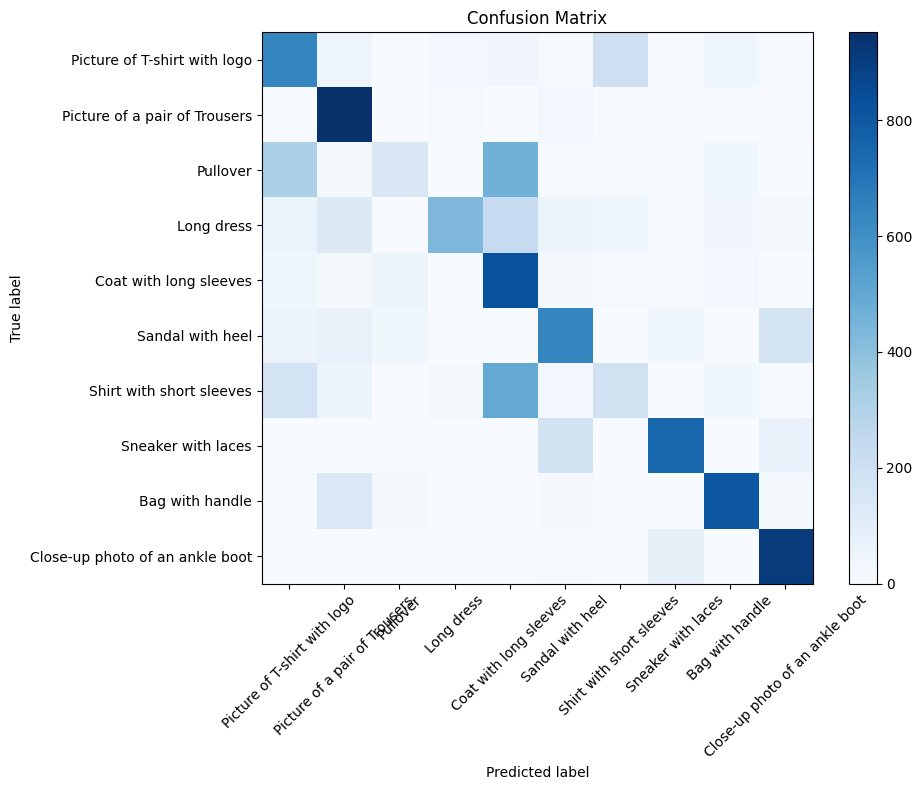

In [46]:
CLASS_NAMES = [
    "Picture of T-shirt with logo",
    "Picture of a pair of Trousers",
    "Pullover",
    "Long dress",
    "Coat with long sleeves",
    "Sandal with heel",
    "Shirt with short sleeves",
    "Sneaker with laces",
    "Bag with handle",
    "Close-up photo of an ankle boot"
]
textEmbed = get_text_embeddings(CLASS_NAMES)
#print(textEmbed)
y_true, y_pred = [], []

for pixel_values, labels in test_loader:
    features = get_image_embeddings(pixel_values)
    batch_similarity = get_cosine_similarity(features, textEmbed)  # shape: (batch_size, num_classes)
    
    # Pick the class with highest similarity
    predicted_classes = torch.argmax(batch_similarity, dim=1)
    
    # Append to lists
    y_true.extend(labels.cpu().numpy())  # convert labels to numpy
    y_pred.extend(predicted_classes.cpu().numpy())  # convert predictions to numpy

# Report the accuracy
accuracy = accuracy_score(y_true, y_pred)
print("Test accuracy:", accuracy)
# # Report the confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()
plot_confusion_matrix(y_true, y_pred, CLASS_NAMES)

Reflection: How did your detailed prompts affect the zero-shot classification performance? Did you see a significant improvement compared to the baseline? What insights did you gain about the model's understanding of the classes? Do you think that with more effort you could further improve the performance? If so, how?

In [9]:
#more detailed prompts slightly improved the accuracy of the classification, but interestingly, when I tried to distinguish 
#between different types of sandals (heel vs flat sole) it was much worse (35%).  Only improvements came with more detailed descriptions 
# of each item.. but there was a trade-off.. I gained 1% accuracy, but then it went down again with more description.

#I understand that more description helps capture the labels associated with each item.. but im not sure what I should do in order to really
#bump up the accuracy.. seems like description can only take you so far.  If i really wanted to improve performance, I think 
#I would randomly look at much more pictures of the items and try my best to come up with a better description of them based
#on what I see.  I thought I was doing that with my sandal example, but I guess not.

## Visualizing Image Embeddings with UMAP

To better understand how the model perceives the different classes, we can visualize the image embeddings using UMAP (Uniform Manifold Approximation and Projection). UMAP is a dimensionality reduction technique that helps us see how similar or dissimilar the embeddings are in a lower-dimensional space.

By visualizing the embeddings, we can gain insights into how well the model can distinguish certain images, even without considering the text prompts. This can help us identify clusters of similar images and see if there are any overlaps between classes.

You should:

- [ ] Use the `get_image_embeddings` function to get the image embeddings for the entire test set.
- [ ] Use UMAP to reduce the dimensionality of the image embeddings to 2D.
- [ ] Plot the 2D embeddings, coloring each point by its true class label.

You may need to install the `umap-learn` library if you haven't already. You can do this by running `pip install umap-learn`.

In [41]:
# Uncomment the following line to install UMAP if you haven't already
!pip install umap-learn

/Users/adamhealey/miniforge3/envs/dsi_env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


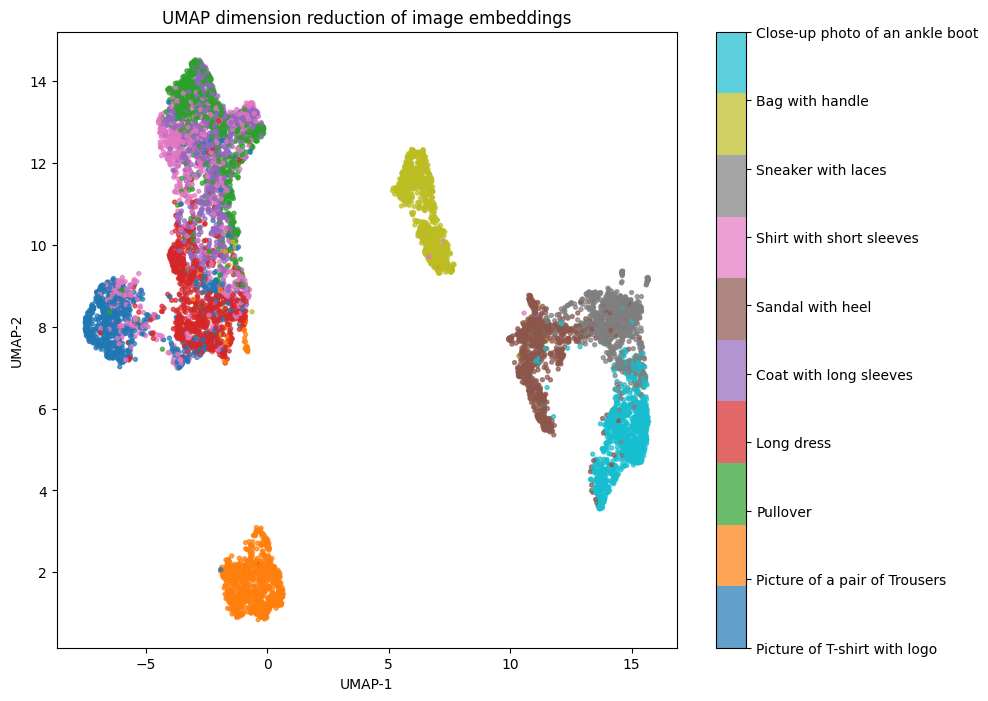

In [ ]:
from umap import UMAP

# ------------------------------------------------------------
# 1. Collect image embeddings
# ------------------------------------------------------------
all_img_emb = []
all_labels  = []

for pixel_values, labels in test_loader:
    features = get_image_embeddings(pixel_values)
    all_img_emb.append(features.cpu().numpy())
    all_labels.append(labels.cpu().numpy())

# Concatenate across all batches
all_img_emb = np.concatenate(all_img_emb, axis=0)
all_labels  = np.concatenate(all_labels, axis=0)


# ------------------------------------------------------------
# 2. Fit UMAP
# ------------------------------------------------------------

reduced = UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embedding_2d = reduced.fit_transform(all_img_emb)


# ------------------------------------------------------------
# 3. Plot coloured by ground-truth label
# ------------------------------------------------------------

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embedding_2d[:, 0], 
    embedding_2d[:, 1], 
    #c=colors,
    c=all_labels, 
    cmap='tab10',
    s=8, 
    alpha=0.7
)
#plt.colorbar(scatter, ticks=range(len(CLASS_NAMES)), label='Class Label')
plt.title("UMAP dimension reduction of image embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

colorbar = plt.colorbar(scatter)
colorbar.set_ticks(range(len(CLASS_NAMES)))
colorbar.set_ticklabels(CLASS_NAMES)


plt.show()


In [ ]:
#Answer to reflection below:
# It looks like it would be very difficult to distinguish between long dresses, pullovers and coats with long sleeves
# That seems pretty intuitive.. considering they all kinda look like in the images themselves.  Bags and trousers are very distinct from one another..
# also, im impressed with the distinction between sandals, boots and sneakers.. I expected them to be more like the dress/coat cluster.

The UMAP embeddings allow us to see how separable or non-separable different classes are with our specific model. If two specific images are very similar, then they will be placed near each other on this graph. 

Reflection: Do you notice any challenges in distinguishing images based on this figure? Are there any types of clothing in the dataset which the model has no trouble distinguishing from the others?

## Mini-Experiment

In this section, you will conduct a mini-experiment of your choice to further explore the capabilities of zero-shot classification with transformers. This can be anything you'd like, but here are some ideas to get you started.

### A. Alternative Model

So far we have been utilizing OpenAI's CLIP model for zero-shot classification. However, there are many other vision–language models available in the `transformers` library that you can experiment with. For example, there are larger CLIP models such as [clip-vit-large-patch14](https://huggingface.co/openai/clip-vit-large-patch14), and open-source versions such as [laion/CLIP-ViT-B-32-laion2B-s34B-b79K](https://huggingface.co/laion/CLIP-ViT-B-32-laion2B-s34B-b79K). You can also search huggingface [here](https://huggingface.co/models?sort=trending&search=clip) to find other models that might be suitable for zero-shot classification.

You can try using a different model to see if it improves the zero-shot classification performance. You should:
- [ ] Load a different model and processor from the `transformers` library.
- [ ] Run the zero-shot classification baseline with the new model and report the accuracy and confusion matrix.
- [ ] Reflect on the performance of the new model compared to the original CLIP model
  - How does the new model perform compared to the original CLIP model?
  - Do you notice any differences in the types of errors made by the new model?

### B. Multiple-Description Classification

Another interesting experiment is to explore multiple-description classification. *This involves providing multiple text prompts for each class, allowing the model to choose the most relevant one. For example, instead of just "T-shirt/top", you could provide "a photo of a T-shirt", "a photo of a top", and "a photo of a shirt". This can help the model better understand the class and increases the likelihood of a correct prediction. You should:

- [ ] Create a list of multiple prompts for each class.
- [ ] Use the `get_text_embeddings` function to create text embeddings for the multiple prompts.
- [ ] Run the zero-shot classification baseline again using the multiple prompts and report the accuracy and confusion matrix.
- [ ] Consider the model to be correct if it guesses *any* of the prompts belonging to the correct class.

### C. Top-K Classification

In some classification tasks, it can be useful to consider if the right answer is among the top K (e.g. top 3) predictions. This can be particularly useful in cases where the model is uncertain or when there are multiple similar classes. You should:

- [ ] Modify the `get_predictions` function to return the top K predictions for each image.
- [ ] Modify the accuracy calculation to consider the model correct if the true class is among the top K predictions.
- [ ] Report the accuracy and confusion matrix for the top K predictions. Report at least two different values of K (e.g. K=2 and K=4).

### D. Other Ideas

You are welcome to come up with your own mini-experiment! Explain your idea in the report and implement it. Did it work as you expected? What did you learn from it?

In [ ]:
import open_clip
from open_clip import create_model_and_transforms, tokenize

print(open_clip.list_pretrained())

[('RN50', 'openai'), ('RN50', 'yfcc15m'), ('RN50', 'cc12m'), ('RN101', 'openai'), ('RN101', 'yfcc15m'), ('RN50x4', 'openai'), ('RN50x16', 'openai'), ('RN50x64', 'openai'), ('ViT-B-32', 'openai'), ('ViT-B-32', 'laion400m_e31'), ('ViT-B-32', 'laion400m_e32'), ('ViT-B-32', 'laion2b_e16'), ('ViT-B-32', 'laion2b_s34b_b79k'), ('ViT-B-32', 'datacomp_xl_s13b_b90k'), ('ViT-B-32', 'datacomp_m_s128m_b4k'), ('ViT-B-32', 'commonpool_m_clip_s128m_b4k'), ('ViT-B-32', 'commonpool_m_laion_s128m_b4k'), ('ViT-B-32', 'commonpool_m_image_s128m_b4k'), ('ViT-B-32', 'commonpool_m_text_s128m_b4k'), ('ViT-B-32', 'commonpool_m_basic_s128m_b4k'), ('ViT-B-32', 'commonpool_m_s128m_b4k'), ('ViT-B-32', 'datacomp_s_s13m_b4k'), ('ViT-B-32', 'commonpool_s_clip_s13m_b4k'), ('ViT-B-32', 'commonpool_s_laion_s13m_b4k'), ('ViT-B-32', 'commonpool_s_image_s13m_b4k'), ('ViT-B-32', 'commonpool_s_text_s13m_b4k'), ('ViT-B-32', 'commonpool_s_basic_s13m_b4k'), ('ViT-B-32', 'commonpool_s_s13m_b4k'), ('ViT-B-32', 'metaclip_400m'), ('V

In [38]:
model_name = "ViT-B-32"
pretrained = "laion2b_s34b_b79k"  

model, preprocess, tokenizer = create_model_and_transforms(model_name, pretrained=pretrained)
device = "mps"  # or "cuda" / "cpu"
model.to(device).eval()

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elementwise_affine

In [52]:
from open_clip import tokenize
CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
prompts = [f"a photo of a {cls.lower()}" for cls in CLASS_NAMES]
text_tokens = tokenize(prompts).to(device)



In [53]:
with torch.no_grad():
    text_emb = model.encode_text(text_tokens)
    text_emb /= text_emb.norm(dim=-1, keepdim=True)


In [54]:
#get the image embeddings 
#set up a new function to maintain the old one.
def get_image_embeddings_new(images):
    images = images.to(device)
    with torch.no_grad():
        img_features = model.encode_image(images)
        img_features /= img_features.norm(dim=-1, keepdim=True)
    return img_features


Test accuracy: 0.7705


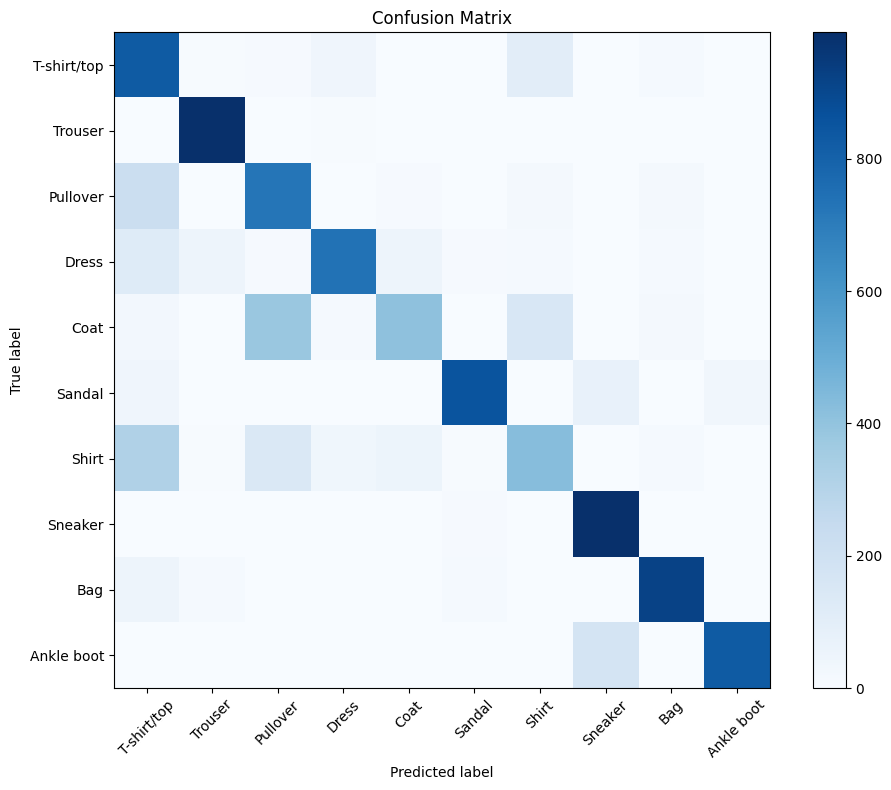

In [ ]:
y_true, y_pred = [], []

for pixel_values, labels in test_loader:
    features = get_image_embeddings_new(pixel_values)
    batch_similarity = get_cosine_similarity(features, text_emb) 
    # Pick the class with highest similarity
    predicted_classes = torch.argmax(batch_similarity, dim=1)
    
    # Append to lists
    y_true.extend(labels.cpu().numpy())  # convert labels to numpy
    y_pred.extend(predicted_classes.cpu().numpy())  # convert predictions to numpy

# Report the accuracy
accuracy = accuracy_score(y_true, y_pred)
print("Test accuracy:", accuracy)
# # Report the confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()
plot_confusion_matrix(y_true, y_pred, CLASS_NAMES)

/Users/adamhealey/miniforge3/envs/dsi_env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


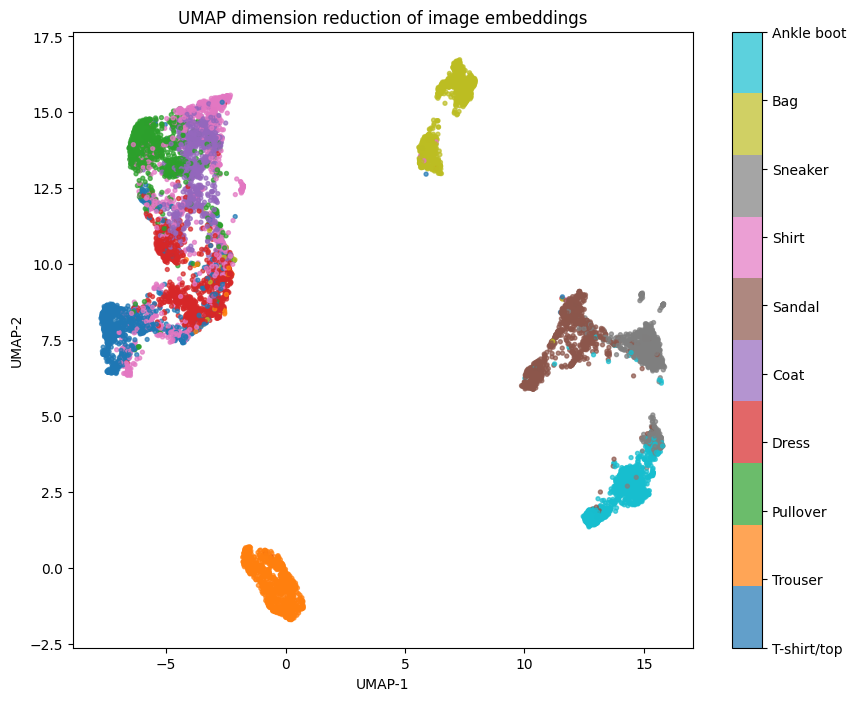

In [ ]:
from umap import UMAP

# ------------------------------------------------------------
# 1. Collect image embeddings
# ------------------------------------------------------------
all_img_emb = []
all_labels  = []

for pixel_values, labels in test_loader:
    features = get_image_embeddings_new(pixel_values)
    all_img_emb.append(features.cpu().numpy())
    all_labels.append(labels.cpu().numpy())

# Concatenate across all batches
all_img_emb = np.concatenate(all_img_emb, axis=0)
all_labels  = np.concatenate(all_labels, axis=0)


# ------------------------------------------------------------
# 2. Fit UMAP
# ------------------------------------------------------------

reduced = UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embedding_2d = reduced.fit_transform(all_img_emb)


# ------------------------------------------------------------
# 3. Plot coloured by ground-truth label
# ------------------------------------------------------------


plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embedding_2d[:, 0], 
    embedding_2d[:, 1], 
    #c=colors,
    c=all_labels, 
    cmap='tab10',
    s=8, 
    alpha=0.7
)
plt.title("UMAP dimension reduction of image embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

colorbar = plt.colorbar(scatter)
colorbar.set_ticks(range(len(CLASS_NAMES)))
colorbar.set_ticklabels(CLASS_NAMES)


plt.show()


### Short Report

In this section, you will write a short report summarizing your findings from the mini-experiment. The report should include the following sections:

- **Introduction**: Briefly describe the mini-experiment you conducted and its objectives.
- **Methodology**: Explain the steps you took to conduct the experiment, including any modifications you made to the code or model.
- **Results**: Present the results of your experiment.
- **Discussion**: Reflect on the performance of the model and the implications of your findings. Consider the strengths and weaknesses of zero-shot transformers versus a trained CNN.

## Introduction
The mini-experiment I selected aimed to improve the zero-shot classification task by using a larger training set, upgrading from the baseline model, `openai/clip-vit-base-patch32`, to `ViT-B-32`. I chose this experiment over other options because, while training the baseline classifier, I had already attempted improvements using multiple descriptors for the same item. Multiple descriptors did not improve classification accuracy, so I hypothesized that the most significant improvement would result from leveraging a larger, more diverse dataset.  

As a result, the goal of this experiment was straightforward: to evaluate whether a larger CLIP-trained model could enhance image classification accuracy using the same `CLASS_NAMES` as the baseline model.

## Methodology
To implement this strategy, I first identified which pretrained weights were compatible with the alternative CLIP transformer models (by running: `print(open_clip.list_pretrained())`), selecting `ViT-B-32:laion2B-s32B-b82K`. I then tokenized both the `CLASS_NAMES` and the images, creating a modified `image_embeddings` function to distinguish this implementation from the baseline approach. Using this setup, I re-ran the image classification and calculated the corresponding accuracy scores, enabling a direct one-to-one comparison with the results from the baseline model using the same class names.

## Results
As predicted, the accuracy achieved with the larger pretrained dataset showed a **15% improvement** over the baseline model (~62% vs 77% accuracy). UMAP visualization further revealed clearer separation among previously overlapping categories such as *shirt*, *dress*, and *coat*. However, *T-shirt* instances remained interspersed with other classes, indicating that this category remains the most challenging to distinguish.  

Improved clustering was observed for images labeled as *Bag*, which now formed two distinct groups. Manual inspection suggests that the model may now be able to differentiate between dark and light bags, or between those with and without carrying handles. Further experimentation is required to confirm this.

## Discussion
Compared to CNN models, one advantage of using zero-shot classifiers is that their training is already complete, allowing immediate use of the vast amount of prior work invested in large pretrained models. However, this also means the underlying training data may be excessive for a specific classification task. For example, when I experimented with a larger CLIP training set (`ViT-g-14`), the process ran for over 30 minutes without producing any output. While using a much larger, well-trained dataset might ultimately improve results, it comes with a significant tradeoff in computational efficiency.

In contrast, convolutional neural networks (CNNs) are trained directly on the dataset of interest, often resulting in higher accuracy and specificity. This is particularly valuable when working with a unique dataset that is not well-represented or described elsewhere. However, this approach requires a large number of labeled examples for training, which adds additional time and effort.


🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 02/11/2025`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb)
    * The Lab 4 notebook (labs/lab_4.ipynb)
    * The Lab 5 notebook (labs/lab_5.ipynb)
    * The Lab 6 notebook (labs/lab_6.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.